<table style="width:100%; border:none; background:transparent;">
  <tr style="border:none;">
    <td style="border:none; text-align:left; vertical-align:middle; width:22%;">
      <img src="./logos/EOSIAL_logo_Sapienza_white_background.bmp" alt="EOSIAL / Sapienza University of Rome" style="max-height:85px;">
    </td>
    <td style="border:none; text-align:center; vertical-align:middle;">
      <h1 style="margin:0; font-size:1.6em;">Fire Detection with MTG-FCI Satellite Imagery</h1>
    </td>
    <td style="border:none; text-align:right; vertical-align:middle; width:22%;">
      <img src="./logos/agh_znk_wbr_rgb_150ppi.jpg" alt="AGH University of Krakow" style="max-height:85px;">
    </td>
  </tr>
</table>

**AGH University of Krakow — Aerospace Engineering**  
**Author:** Valerio Pampanoni ([valerio.pampanoni@uniroma1.it](mailto:valerio.pampanoni@uniroma1.it))  
**Affiliation:** Sapienza University of Rome — EOSIAL Lab

---

### Case Study: Biebrza National Park Wildfire (April 2025)

On **April 20, 2025**, a major wildfire broke out in **Biebrza National Park**, Poland’s largest national park and one of Europe’s most important wetland habitats. The fire, fuelled by dry peatland and marshland vegetation, burned thousands of hectares and was monitored by the **Copernicus Emergency Management Service** (activation [EMSR801](https://mapping.emergency.copernicus.eu/news/wildfire-in-poland/)).

In this notebook, we implement a simplified **fire detection algorithm** based on the **MODIS Collection 5** approach (Giglio et al., 2003), adapted for the **MTG-FCI** (Meteosat Third Generation — Flexible Combined Imager) instrument. MTG-FCI provides imagery every **10 minutes** over Europe, enabling near-real-time fire monitoring.

### What you will learn

1. How to extract and process **MTG-FCI** satellite data (FDHSI + HRFI products)
2. How **mid-wave infrared (MWIR, 3.8 µm)** radiation relates to fire detection
3. How to implement **threshold-based potential fire detection**
4. How to apply **contextual confirmation** using local background statistics
5. How to compute **Fire Radiative Power (FRP)** and **Fire Radiative Energy (FRE)**
6. How to visualise results on **interactive maps** with leafmap

## 0. Environment Setup

This notebook requires a Python environment with GDAL, NumPy, SciPy, matplotlib, geopandas, pyorbital, and leafmap. See `environment.yml` for the full conda environment specification.

> **Note:** GDAL must be installed via conda (not pip) to ensure the C/C++ bindings are properly linked.

In [13]:
import datetime
import os
import re
import zipfile
from pathlib import Path

import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import geopandas as gpd
import pandas as pd
from osgeo import gdal, osr
from pyorbital.astronomy import sun_zenith_angle
import leafmap

gdal.UseExceptions()

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Configuration

We define the key parameters that control the entire pipeline:

- **Band mapping:** which MTG-FCI bands to extract from the FDHSI and HRFI products
- **Detection thresholds:** the MWIR brightness temperature and MWIR–TIR difference thresholds for flagging potential fires
- **Contextual confirmation coefficients (C1–C4):** based on the MODIS Collection 5 algorithm
- **Area of interest:** approximate bounding box for Biebrza National Park

> **Note — FDHSI vs HRFI:** MTG-FCI provides two product types over Europe. **FDHSI** (Full Disk High Spectral Imaging) contains all 16 spectral channels at ~2 km resolution. **HRFI** (High Resolution Fast Imaging) provides 4 key channels at ~1 km resolution. For fire detection, the critical **3.8 µm (MWIR)** band is only available at 1 km in the HRFI product.

In [14]:
# ---- Paths ----
BASE_DIR = Path("").resolve().parent  # notebook is in notebooks/
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
TEMP_DIR = BASE_DIR / "temp"

OUTPUT_DIR.mkdir(exist_ok=True)
TEMP_DIR.mkdir(exist_ok=True)

# ---- MTG-FCI band mapping ----
FDHSI_BANDS = {
    "vis_06": "RED_REF",  # 0.64 µm — red reflectance
    "vis_08": "NIR_08_REF",  # 0.86 µm — NIR reflectance
    "nir_13": "NIR_13_REF",  # 1.3 µm  — NIR reflectance (cirrus / cloud masking)
    "nir_22": "SWIR_22_REF",  # 2.2 µm  — shortwave IR reflectance
    "ir_123": "TIR_12_BT",  # 12.3 µm — brightness temperature
    "natural_color": "NCC",  # Natural colour composite (RGB)
}
HRFI_BANDS = {
    "ir_38": "MWIR_BT",  # 3.8 µm  — brightness temperature (KEY)
    "ir_38_rad": "MWIR_RAD",  # 3.8 µm  — radiance
    "ir_105": "TIR_11_BT",  # 10.5 µm — brightness temperature
}

# ---- Detection thresholds ----
MWIR_THRESHOLD = 310.0
MWIR_TIR_DIFF_THRESHOLD = 10.0

# Contextual confirmation coefficients
C1_ABSOLUTE_MWIR = 360.0
C2_DIFF_STD_MULT = 3.0
C3_DIFF_ABSOLUTE = 5.5
C4_MWIR_STD_MULT = 2.5
CONTEXT_WINDOW = 21

# ---- Biebrza bounding box ----
BIEBRZA_BBOX = {
    "lon_min": 22.4, "lon_max": 23.6,
    "lat_min": 53.3, "lat_max": 53.75,
}

print(f"Data directory: {DATA_DIR}")
print(f"  FDHSI files: {len(list(DATA_DIR.glob('MTG_FDHSI_POL_*.zip')))}")
print(f"  HRFI files:  {len(list(DATA_DIR.glob('MTG_HRFI_POL_*.zip')))}")

Data directory: /home/michal/agh/rsaia-labs/lab_4/data
  FDHSI files: 13
  HRFI files:  13


## 2. Utility Functions

These helper functions handle the low-level operations: extracting bands from zip archives, reading GeoTIFF rasters, computing coordinate grids, and resampling between the FDHSI and HRFI resolution grids.

In [15]:
def discover_timestamps(data_dir):
    """
    Scan the data directory and return a sorted list of datetime objects
    for which FDHSI, HRFI, and CLM zip files are all present.

    Parameters
    ----------
    data_dir : Path
        Directory containing the MTG zip archives.

    Returns
    -------
    list of datetime.datetime
        Sorted list of available observation times.
    """
    pattern = re.compile(r"MTG_FDHSI_POL_(\d{12})\.zip")
    timestamps = []
    for f in sorted(data_dir.glob("MTG_FDHSI_POL_*.zip")):
        m = pattern.match(f.name)
        if not m:
            continue
        dtstr = m.group(1)
        dtime = datetime.datetime.strptime(dtstr, "%Y%m%d%H%M")
        # Only include if the HRFI file is also present
        hrfi = data_dir / f"MTG_HRFI_POL_{dtstr}.zip"
        if hrfi.exists():
            timestamps.append(dtime)
    return timestamps


def extract_bands_from_zip(zip_path, band_names, out_dir):
    """
    Extract specific GeoTIFF bands from a zip archive into a directory.

    Parameters
    ----------
    zip_path : Path
        Path to the zip file.
    band_names : list of str
        Band filenames (without .tif extension) to extract.
    out_dir : Path
        Destination directory for extracted files.

    Returns
    -------
    dict
        {band_name: extracted_file_path_str}
    """
    extracted = {}
    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.namelist():
            for band in band_names:
                if member.endswith(band + ".tif"):
                    out_path = out_dir / os.path.basename(member)
                    if not out_path.exists():
                        data = zf.read(member)
                        with open(out_path, "wb") as f:
                            f.write(data)
                    extracted[band] = str(out_path)
    return extracted


def read_band_as_masked_array(file_path, band_num=1):
    """
    Read a single band from a GeoTIFF into a NumPy masked array.

    The GDAL NoData value is used as the mask; NaN values are also masked.
    Accepts both regular file paths and GDAL virtual filesystem paths
    such as /vsizip/.

    Parameters
    ----------
    file_path : str
        Path to the GeoTIFF (or /vsizip/ path).
    band_num : int
        Band number to read (1-indexed).

    Returns
    -------
    numpy.ma.MaskedArray
    """
    ds = gdal.Open(file_path)
    if ds is None:
        raise ValueError(f"Could not open: {file_path}")
    band = ds.GetRasterBand(band_num)
    nodata = band.GetNoDataValue()
    arr = band.ReadAsArray().astype(np.float32)
    ds = None

    if nodata is not None and np.isnan(nodata):
        return ma.masked_invalid(arr)
    elif nodata is not None:
        return ma.masked_values(arr, nodata)
    else:
        return ma.masked_invalid(arr)


def get_geotransform(file_path):
    """Return the GDAL 6-element geotransform for a raster file."""
    ds = gdal.Open(file_path)
    gt = ds.GetGeoTransform()
    ds = None
    return gt


def get_projection_wkt(file_path):
    """Return the WKT projection string for a raster file."""
    ds = gdal.Open(file_path)
    wkt = ds.GetProjection()
    ds = None
    return wkt


def get_raster_extent(file_path):
    """Return [xmin, ymin, xmax, ymax] for a raster file."""
    ds = gdal.Open(file_path)
    gt = ds.GetGeoTransform()
    w, h = ds.RasterXSize, ds.RasterYSize
    ds = None
    xmin, ymax = gt[0], gt[3]
    xmax = xmin + w * gt[1] + h * gt[2]
    ymin = ymax + w * gt[4] + h * gt[5]
    return [xmin, ymin, xmax, ymax]


def get_lat_lon_grids(file_path, pixel_center=True):
    """
    Compute per-pixel longitude and latitude grids in WGS84 (EPSG:4326).

    Parameters
    ----------
    file_path : str
        Path to a georeferenced raster.
    pixel_center : bool
        If True, return coordinates for pixel centres.

    Returns
    -------
    lons, lats : numpy.ndarray
        2D arrays of the same shape as the raster.
    """
    ds = gdal.Open(file_path)
    gt = ds.GetGeoTransform()
    width, height = ds.RasterXSize, ds.RasterYSize
    src_wkt = ds.GetProjection()
    ds = None

    ox, pw, xr, oy, yr, ph = gt
    if pixel_center:
        ox += pw / 2.0
        oy += ph / 2.0

    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    x_nat = ox + cols * pw + rows * xr
    y_nat = oy + cols * yr + rows * ph

    src_srs = osr.SpatialReference()
    src_srs.ImportFromWkt(src_wkt)
    tgt_srs = osr.SpatialReference()
    tgt_srs.ImportFromEPSG(4326)
    tgt_srs.SetAxisMappingStrategy(osr.OAMS_TRADITIONAL_GIS_ORDER)

    transform = osr.CoordinateTransformation(src_srs, tgt_srs)
    pts = np.vstack((x_nat.ravel(), y_nat.ravel(), np.zeros(x_nat.size))).T
    transformed = np.array(transform.TransformPoints(pts))

    lons = transformed[:, 0].reshape(height, width)
    lats = transformed[:, 1].reshape(height, width)
    return lons, lats


def resample_to_target(source_path, target_shape, out_bounds, method="nearest"):
    """
    Resample a raster to a target grid using GDAL Warp (in-memory).

    Parameters
    ----------
    source_path : str
        Path to the source raster.
    target_shape : tuple
        (rows, cols) of the desired output.
    out_bounds : list
        [xmin, ymin, xmax, ymax] output bounds.
    method : str
        Resampling algorithm ('nearest', 'bilinear', etc.).

    Returns
    -------
    numpy.ndarray
    """
    methods = {"nearest": gdal.GRA_NearestNeighbour, "bilinear": gdal.GRA_Bilinear}
    ds = gdal.Open(source_path)
    mem_ds = gdal.Warp(
        "", ds, format="MEM",
        width=target_shape[1], height=target_shape[0],
        resampleAlg=methods[method], outputBounds=out_bounds,
    )
    arr = mem_ds.ReadAsArray()
    ds = None
    mem_ds = None
    return arr


def get_pixel_area_grid(geotransform, shape, src_crs_wkt, cache_file=None):
    """
    Compute per-pixel area (km²) using equal-area reprojection (EPSG:6933).

    Results are cached to a .npy file for repeated runs.

    Parameters
    ----------
    geotransform : tuple
        GDAL 6-element geotransform.
    shape : tuple
        (rows, cols).
    src_crs_wkt : str
        Source CRS as WKT.
    cache_file : str or Path, optional
        Path to .npy cache file.

    Returns
    -------
    numpy.ma.MaskedArray
        2D array of pixel areas in km².
    """
    if cache_file and os.path.exists(cache_file):
        return ma.masked_invalid(np.load(cache_file, allow_pickle=True))

    rows, cols = shape
    gt = geotransform
    ci, ri = np.meshgrid(np.arange(cols + 1), np.arange(rows + 1))
    X = gt[0] + ci * gt[1] + ri * gt[2]
    Y = gt[3] + ci * gt[4] + ri * gt[5]

    x_tl, y_tl = X[:-1, :-1].ravel(), Y[:-1, :-1].ravel()
    x_tr, y_tr = X[:-1, 1:].ravel(), Y[:-1, 1:].ravel()
    x_br, y_br = X[1:, 1:].ravel(), Y[1:, 1:].ravel()
    x_bl, y_bl = X[1:, :-1].ravel(), Y[1:, :-1].ravel()

    coords = np.array([[x_tl, y_tl], [x_tr, y_tr],
                       [x_br, y_br], [x_bl, y_bl]]).transpose(2, 0, 1)
    try:
        from shapely import polygons
        geoms = polygons(coords)
    except ImportError:
        from shapely.geometry import Polygon
        geoms = [Polygon(c) for c in coords]

    gs = gpd.GeoSeries(geoms, crs=src_crs_wkt)
    areas = gs.to_crs("EPSG:6933").area.values.reshape(rows, cols)
    area_km2 = ma.masked_array(areas, mask=~np.isfinite(areas)) / 1e6

    if cache_file:
        np.save(cache_file, area_km2.filled(np.nan))
    return area_km2


print("Utility functions defined.")

Utility functions defined.


## 3. Fire Detection Functions

This is the core of the algorithm.

### 3.1 Data Cube Construction

The **data cube** is a dictionary mapping band tags to 2D arrays, all co-registered to the HRFI 1 km grid.

### 3.2 Cloud Masking

We use a simple **threshold-based cloud mask** combining three tests (OR logic):

| Test | Band | Condition | Rationale |
|------|------|-----------|-----------|
| Bright visible | RED (0.64 μm) | reflectance > 0.13 | Cloud tops are bright |
| Cirrus | NIR (1.3 μm) | reflectance > 0.01 | Only high cirrus reflects at 1.3 μm |
| Cold tops | TIR (12.3 μm) | BT < 265 K | Cloud tops are cold |

### 3.3 Potential Hotspot Detection

A pixel is flagged if: **MWIR BT > 310 K** AND **MWIR \u2013 TIR > 10 K**

> **Why 3.8 μm?** The Planck function peaks near 3.8 μm at ~800 K (typical fire temperature). At background ~300 K the 3.8 μm radiance is very low, so even a small sub-pixel fire causes a dramatic increase. The 10.5 μm channel peaks near 300 K and is much less sensitive to fire.

### 3.4 Contextual Confirmation (MODIS Collection 5)

$$\text{C1: } T_{\text{MWIR}} > 360 \text{ K}$$
$$\text{C2: } \Delta T > \overline{\Delta T}_{\text{bg}} + C_2 \cdot \sigma_{\Delta T}$$
$$\text{C3: } \Delta T > \overline{\Delta T}_{\text{bg}} + 5.5 \text{ K}$$
$$\text{C4: } T_{\text{MWIR}} > \overline{T}_{\text{MWIR,bg}} + C_4 \cdot \sigma_{\text{MWIR}}$$

Confirmed if: **C1** OR (**C2** AND **C3** AND **C4**)

### 3.5 Fire Radiative Power

$$\text{FRP [MW]} = A_{\text{pixel}} \times 4.34 \times 10^{-19} \times (T_{\text{fire}}^8 - T_{\text{bg}}^8)$$

In [16]:
def build_data_cube(fdhsi_files, hrfi_files, target_shape, out_bounds):
    """
    Load all bands into a dictionary, resampling FDHSI bands to the
    HRFI resolution grid.

    Parameters
    ----------
    fdhsi_files : dict
        {band_name: file_path} for FDHSI bands.
    hrfi_files : dict
        {band_name: file_path} for HRFI bands.
    target_shape : tuple
        (rows, cols) of the HRFI grid.
    out_bounds : list
        [xmin, ymin, xmax, ymax] of the HRFI grid.

    Returns
    -------
    dict
        {tag: masked_array} for all bands.
    """
    cube = {}

    # HRFI bands are already at target resolution
    for band_name, tag in HRFI_BANDS.items():
        if band_name in hrfi_files:
            arr = read_band_as_masked_array(hrfi_files[band_name])
            np.place(arr, np.isnan(arr), 0.0)
            if hasattr(arr, 'fill_value') and arr.fill_value > 0.0:
                arr.fill_value = 0.0
            cube[tag] = arr

    # FDHSI bands need resampling to the HRFI grid
    for band_name, tag in FDHSI_BANDS.items():
        if band_name not in fdhsi_files:
            continue
        if tag == "NCC":
            arr_r = read_band_as_masked_array(fdhsi_files[band_name], band_num=1)
            arr_g = read_band_as_masked_array(fdhsi_files[band_name], band_num=2)
            arr_b = read_band_as_masked_array(fdhsi_files[band_name], band_num=3)
            cube[tag] = np.dstack([arr_r, arr_g, arr_b])
        else:
            resampled = resample_to_target(
                fdhsi_files[band_name], target_shape, out_bounds, method="nearest"
            )
            np.place(resampled, np.isnan(resampled), 0.0)
            cube[tag] = ma.masked_values(resampled, 0.0)

    return cube


def apply_exclusion_mask(cube, mask):
    """
    Mask out pixels in all cube bands (e.g. clouds, nighttime).

    Parameters
    ----------
    cube : dict
    mask : numpy.ndarray (bool)
        True = exclude this pixel.

    Returns
    -------
    dict
    """
    masked_cube = {}
    for key, arr in cube.items():
        if key == "NCC":
            masked_cube[key] = arr
            continue
        new_arr = arr.data.copy()
        fill = arr.fill_value if hasattr(arr, 'fill_value') else 0.0
        np.place(new_arr, mask, fill)
        masked_cube[key] = ma.masked_values(new_arr, fill)
    return masked_cube


def compute_cloud_mask(cube,
                       red_thresh=0.13,
                       nir13_thresh=0.01,
                       tir12_thresh=265.0):
    """
    Simple threshold-based cloud mask derived directly from the data cube.

    A pixel is flagged as cloudy if ANY of the following conditions is true:
      - Red reflectance (0.64 µm) > red_thresh       (bright cloud tops)
      - NIR 1.3 µm reflectance    > nir13_thresh      (cirrus detection)
      - TIR 12.3 µm BT           < tir12_thresh  [K]  (cold cloud tops)

    Parameters
    ----------
    cube : dict
        Data cube containing 'RED_REF', 'NIR_13_REF', and 'TIR_12_BT'.
    red_thresh : float
        Red reflectance threshold (default 0.13).
    nir13_thresh : float
        NIR 1.3 µm reflectance threshold (default 0.01).
    tir12_thresh : float
        TIR 12.3 µm brightness temperature threshold in K (default 265.0).

    Returns
    -------
    numpy.ndarray (bool)
        True = cloudy pixel.
    """
    mask_red = cube["RED_REF"].filled(0) > red_thresh
    mask_nir = cube["NIR_13_REF"].filled(0) > nir13_thresh
    mask_tir = cube["TIR_12_BT"].filled(999) < tir12_thresh

    return mask_red | mask_nir | mask_tir


def detect_potential_hotspots(cube, mwir_thresh, diff_thresh):
    """
    MODIS Collection 5 potential hotspot detection (daytime).

    A pixel is flagged if:
      (1) MWIR brightness temperature > mwir_thresh, AND
      (2) MWIR – TIR brightness temperature difference > diff_thresh.

    Parameters
    ----------
    cube : dict
    mwir_thresh : float
        MWIR BT threshold (K).
    diff_thresh : float
        MWIR–TIR difference threshold (K).

    Returns
    -------
    numpy.ndarray (bool)
    """
    mwir = cube["MWIR_BT"]
    tir = cube["TIR_11_BT"]
    return np.logical_and(mwir > mwir_thresh, (mwir - tir) > diff_thresh)


def compute_background_stats(image, fire_mask, window_size):
    """
    Compute windowed background mean and MAD, excluding fire pixels.

    Uses FFT-based convolution for efficiency. Fire pixels are excluded
    so that active fires do not bias the background statistics.

    Parameters
    ----------
    image : numpy.ma.MaskedArray
        Input band (e.g. MWIR BT).
    fire_mask : numpy.ndarray (bool)
        True = fire pixel (excluded from background computation).
    window_size : int
        Side length of the square window.

    Returns
    -------
    bg_mean, bg_mad : numpy.ndarray
        Same shape as input.
    """
    data = image.filled(0.0).astype(float)
    base_mask = ma.getmaskarray(image)
    valid = (~(base_mask | fire_mask)).astype(float)
    kernel = np.ones((window_size, window_size), dtype=float)

    def fft_conv(a, b):
        s = (a.shape[0] + b.shape[0] - 1, a.shape[1] + b.shape[1] - 1)
        out = np.fft.irfftn(np.fft.rfftn(a, s=s) * np.fft.rfftn(b, s=s), s=s)
        pm, pn = (b.shape[0] - 1) // 2, (b.shape[1] - 1) // 2
        return out[pm:pm + a.shape[0], pn:pn + a.shape[1]]

    count = fft_conv(valid, kernel)
    with np.errstate(divide="ignore", invalid="ignore"):
        sum_x = fft_conv(data * valid, kernel)
        sum_x2 = fft_conv((data ** 2) * valid, kernel)
        bg_mean = np.where(count > 0, sum_x / count, np.nan)
        bg_var = np.where(count > 0, sum_x2 / count - bg_mean ** 2, np.nan)
        bg_std = np.sqrt(np.maximum(bg_var, 0.0))
    return bg_mean, bg_std


def confirm_hotspots(cube, pot_fire_mask, window_size, c1, c2, c3, c4):
    """
    Contextual confirmation of potential hotspots (daytime).

    Applies the MODIS Collection 5 confirmation tests:
      C1: MWIR BT > c1 (absolute threshold — automatic confirm)
      C2: MWIR–TIR diff > bg_mean + c2 × MAD
      C3: MWIR–TIR diff > bg_mean + c3
      C4: MWIR BT > bg_mean + c4 × MAD

    A pixel is confirmed if: C1 OR (C2 AND C3 AND C4)

    Parameters
    ----------
    cube : dict
    pot_fire_mask : numpy.ndarray (bool)
    window_size : int
    c1, c2, c3, c4 : float
        Confirmation coefficients.

    Returns
    -------
    numpy.ndarray (bool)
    """
    mwir = cube["MWIR_BT"]
    tir = cube["TIR_11_BT"]
    diff = mwir - tir

    mir_mean, mir_mad = compute_background_stats(mwir, pot_fire_mask, window_size)
    diff_mean, diff_mad = compute_background_stats(
        ma.masked_array(diff if not hasattr(diff, 'filled') else diff,
                        mask=ma.getmaskarray(mwir)),
        pot_fire_mask, window_size,
    )

    mwir_vals = np.where(pot_fire_mask, mwir.filled(0), 0)
    diff_vals = np.where(pot_fire_mask,
                         diff.filled(0) if hasattr(diff, 'filled') else diff, 0)

    mask_c1 = mwir_vals > c1
    mask_c2 = diff_vals > (diff_mean + c2 * diff_mad)
    mask_c3 = diff_vals > (diff_mean + c3)
    mask_c4 = mwir_vals > (mir_mean + c4 * mir_mad)

    confirmed = np.logical_or(mask_c1,
                              np.logical_and(mask_c2, np.logical_and(mask_c3, mask_c4)))
    confirmed = np.logical_and(confirmed, pot_fire_mask)

    return confirmed


def compute_frp_modis(mwir_bt_fire, mwir_bt_bg, pixel_area_km2):
    """
    Compute Fire Radiative Power using the MODIS equation.

    FRP [MW] = pixel_area [km²] × 4.34×10⁻¹⁹ × (T_fire⁸ – T_bg⁸)

    This relates the 3.8 µm radiance excess to fire radiative power
    via the 8th-power approximation of the Planck function.
    (Wooster et al., 2003; Giglio et al., 2003)

    Parameters
    ----------
    mwir_bt_fire : numpy.ndarray
        MWIR brightness temperature of fire pixels (K).
    mwir_bt_bg : numpy.ndarray
        MWIR background brightness temperature (K).
    pixel_area_km2 : numpy.ndarray
        Area of each pixel (km²).

    Returns
    -------
    numpy.ndarray
        FRP in MW per pixel.
    """
    return pixel_area_km2 * 4.34e-19 * (mwir_bt_fire ** 8 - mwir_bt_bg ** 8)


print("Fire detection functions defined.")

Fire detection functions defined.


## 4. Single-Timestamp Processing Pipeline

The `process_single_datetime` function orchestrates the complete pipeline for one observation:

1. **Extract** bands from zip archives into a temp directory
2. **Build** the data cube (resample FDHSI → HRFI grid)
3. **Compute** solar zenith angle → day/night mask
4. **Apply** cloud mask (threshold-based)
5. **Detect** potential hotspots
6. **Confirm** via contextual background tests (C1–C4)
7. **Compute** FRP for confirmed fire pixels
8. **Export** results as a GeoDataFrame

In [17]:
def _cleanup_temp(temp_dir):
    """Remove extracted .tif files from a per-timestamp temp subdirectory."""
    for f in temp_dir.glob("*.tif"):
        f.unlink()
    try:
        temp_dir.rmdir()
    except OSError:
        pass


def process_single_datetime(dtime, pixel_area_cache=None):
    """
    Run the full fire detection pipeline for one observation timestamp.

    Returns: gdf, cube, confirmed, frp, lons, lats
    """
    dtstr = dtime.strftime("%Y%m%d%H%M")
    fdhsi_zip = DATA_DIR / f"MTG_FDHSI_POL_{dtstr}.zip"
    hrfi_zip = DATA_DIR / f"MTG_HRFI_POL_{dtstr}.zip"

    ts_temp = TEMP_DIR / dtstr
    ts_temp.mkdir(exist_ok=True)

    fdhsi_files = extract_bands_from_zip(fdhsi_zip, list(FDHSI_BANDS.keys()), ts_temp)
    hrfi_files = extract_bands_from_zip(hrfi_zip, list(HRFI_BANDS.keys()), ts_temp)

    ref_file = list(hrfi_files.values())[0]
    target_shape = read_band_as_masked_array(ref_file).shape
    out_bounds = get_raster_extent(ref_file)

    cube = build_data_cube(fdhsi_files, hrfi_files, target_shape, out_bounds)

    lons, lats = get_lat_lon_grids(ref_file, pixel_center=True)
    sza = sun_zenith_angle(dtime, lons, lats)
    mask_night = sza > 85.0

    cloud_mask = compute_cloud_mask(cube)
    exclusion = np.logical_or(mask_night, cloud_mask)
    cube_day = apply_exclusion_mask(cube, exclusion)

    pot_fires = detect_potential_hotspots(cube_day, MWIR_THRESHOLD, MWIR_TIR_DIFF_THRESHOLD)
    n_pot = int(np.sum(pot_fires))

    empty_gdf = gpd.GeoDataFrame(
        columns=["LATITUDE", "LONGITUDE", "ACQ_DATE", "ACQ_TIME", "DATETIME",
                 "SATELLITE", "INSTRUMENT", "BRIGHT_MIR", "BRIGHT_TIR",
                 "MIR_TIR_DIFF", "FRP_MW", "geometry"],
        geometry="geometry", crs="EPSG:4326",
    )

    if n_pot == 0:
        _cleanup_temp(ts_temp)
        return empty_gdf, cube, np.zeros(target_shape, dtype=bool), np.zeros(target_shape), lons, lats

    confirmed = confirm_hotspots(
        cube_day, pot_fires, CONTEXT_WINDOW,
        c1=C1_ABSOLUTE_MWIR, c2=C2_DIFF_STD_MULT,
        c3=C3_DIFF_ABSOLUTE, c4=C4_MWIR_STD_MULT,
    )
    n_confirmed = int(np.sum(confirmed))

    if n_confirmed == 0:
        _cleanup_temp(ts_temp)
        return empty_gdf, cube, confirmed, np.zeros(target_shape), lons, lats

    gt = get_geotransform(ref_file)
    proj_wkt = get_projection_wkt(ref_file)
    pixel_area = get_pixel_area_grid(gt, target_shape, proj_wkt, cache_file=pixel_area_cache)

    mir_bg_mean, _ = compute_background_stats(cube_day["MWIR_BT"], confirmed, CONTEXT_WINDOW)
    frp = np.where(
        confirmed,
        compute_frp_modis(cube_day["MWIR_BT"].filled(0), mir_bg_mean, pixel_area.filled(0)),
        0.0,
    )

    fire_lats = lats[confirmed]
    fire_lons = lons[confirmed]
    df = pd.DataFrame({
        "LATITUDE": fire_lats, "LONGITUDE": fire_lons,
        "ACQ_DATE": dtime.strftime("%Y-%m-%d"), "ACQ_TIME": dtime.strftime("%H:%M"),
        "DATETIME": dtime, "SATELLITE": "MTG-1", "INSTRUMENT": "FCI",
        "BRIGHT_MIR": np.round(cube_day["MWIR_BT"].filled(0)[confirmed], 2),
        "BRIGHT_TIR": np.round(cube_day["TIR_11_BT"].filled(0)[confirmed], 2),
        "MIR_TIR_DIFF": np.round(
            cube_day["MWIR_BT"].filled(0)[confirmed] - cube_day["TIR_11_BT"].filled(0)[confirmed], 2),
        "FRP_MW": np.round(frp[confirmed], 2),
    })
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.LONGITUDE, df.LATITUDE), crs="EPSG:4326"
    )

    _cleanup_temp(ts_temp)
    return gdf, cube, confirmed, frp, lons, lats


print("Processing pipeline defined.")

Processing pipeline defined.


## 5. Discover and Process All Timestamps

Now we run the pipeline across all available timestamps (**13 timestamps** from 12:00 to 14:00 UTC, 10-minute intervals).

In [18]:
timestamps = discover_timestamps(DATA_DIR)
print(f"Found {len(timestamps)} timestamps:")
for t in timestamps:
    print(f"  {t.strftime('%Y-%m-%d %H:%M UTC')}")

pixel_area_cache = str(TEMP_DIR / "pixel_area_POL_MTG.npy")

all_gdfs = []
per_ts_data = {}
frp_total_ts = []
frp_biebrza_ts = []
vis_dtime = None
vis_cube = vis_confirmed = vis_frp = vis_lons = vis_lats = None

print()
for dtime in timestamps:
    print(f"[{dtime.strftime('%H:%M')}] Processing...", end=" ", flush=True)
    gdf, cube, confirmed, frp, lons, lats = process_single_datetime(
        dtime, pixel_area_cache=pixel_area_cache)

    n_fires = len(gdf)
    total_frp = float(np.nansum(frp[confirmed])) if n_fires > 0 else 0.0
    biebrza_mask = (
            (lons >= BIEBRZA_BBOX["lon_min"]) & (lons <= BIEBRZA_BBOX["lon_max"]) &
            (lats >= BIEBRZA_BBOX["lat_min"]) & (lats <= BIEBRZA_BBOX["lat_max"]))
    biebrza_fires = np.logical_and(confirmed, biebrza_mask)
    biebrza_frp = float(np.nansum(frp[biebrza_fires])) if n_fires > 0 else 0.0

    print(f"{n_fires:4d} fires | Total FRP: {total_frp:8.1f} MW | Biebrza FRP: {biebrza_frp:8.1f} MW")
    frp_total_ts.append(total_frp)
    frp_biebrza_ts.append(biebrza_frp)
    if not gdf.empty:
        all_gdfs.append(gdf)
    per_ts_data[dtime] = (cube, confirmed, frp, lons, lats)
    if vis_dtime is None and n_fires > 0:
        vis_dtime, vis_cube, vis_confirmed = dtime, cube, confirmed
        vis_frp, vis_lons, vis_lats = frp, lons, lats

if all_gdfs:
    gdf_all = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True), crs="EPSG:4326")
    print(f"\nTotal fire detections: {len(gdf_all)}")
else:
    gdf_all = gpd.GeoDataFrame()
    print("\nNo fire detections found.")

Found 13 timestamps:
  2025-04-20 12:00 UTC
  2025-04-20 12:10 UTC
  2025-04-20 12:20 UTC
  2025-04-20 12:30 UTC
  2025-04-20 12:40 UTC
  2025-04-20 12:50 UTC
  2025-04-20 13:00 UTC
  2025-04-20 13:10 UTC
  2025-04-20 13:20 UTC
  2025-04-20 13:30 UTC
  2025-04-20 13:40 UTC
  2025-04-20 13:50 UTC
  2025-04-20 14:00 UTC

[12:00] Processing...    3 fires | Total FRP:     79.0 MW | Biebrza FRP:      0.0 MW
[12:10] Processing...    2 fires | Total FRP:     49.6 MW | Biebrza FRP:      0.0 MW
[12:20] Processing...    0 fires | Total FRP:      0.0 MW | Biebrza FRP:      0.0 MW
[12:30] Processing...    1 fires | Total FRP:     19.1 MW | Biebrza FRP:      0.0 MW
[12:40] Processing...    1 fires | Total FRP:     30.8 MW | Biebrza FRP:      0.0 MW
[12:50] Processing...    3 fires | Total FRP:     94.2 MW | Biebrza FRP:     72.0 MW
[13:00] Processing...    4 fires | Total FRP:    172.2 MW | Biebrza FRP:    149.7 MW
[13:10] Processing...    3 fires | Total FRP:    147.8 MW | Biebrza FRP:    119.4 MW

## 6. Static Visualizations

Let’s examine the satellite data and fire detections for the first timestamp with confirmed fires.

In [19]:
def plot_band(arr, title, cmap="gray", vmin=None, vmax=None,
              cbar_label=None, figsize=(10, 8), xlim=None, ylim=None):
    """Plot a 2D array with colorbar; optionally crop to xlim/ylim."""
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.axis("off")
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.colorbar(im, ax=ax, label=cbar_label or "", shrink=0.7)
    plt.tight_layout()
    plt.show()
    return fig


def plot_fire_overlay(background, fire_mask, title, frp_values=None,
                      vmin=270, vmax=320, figsize=(12, 10),
                      xlim=None, ylim=None):
    """Overlay fire detections on a background image."""
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.imshow(background, cmap="gray", vmin=vmin, vmax=vmax)
    if frp_values is not None and np.any(fire_mask):
        fire_display = np.where(fire_mask, frp_values, np.nan)
        im = ax.imshow(np.ma.masked_invalid(fire_display), cmap="YlOrRd", vmin=0,
                       vmax=max(float(np.nanpercentile(frp_values[fire_mask], 95)), 1.0))
        plt.colorbar(im, ax=ax, label="FRP [MW]", shrink=0.7)
    else:
        overlay = np.ma.masked_where(~fire_mask, np.ones_like(fire_mask, float))
        ax.imshow(overlay, cmap="autumn_r", alpha=0.85)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.axis("off")
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.tight_layout()
    plt.show()
    return fig


def plot_ncc(ncc_arr, title, figsize=(12, 10), xlim=None, ylim=None):
    """Plot natural colour composite with contrast stretching."""
    ncc = ncc_arr.copy().astype(float)
    for i in range(3):
        band = ncc[:, :, i]
        valid = band[band > 0]
        if valid.size:
            p2, p98 = np.nanpercentile(valid, [2, 98])
            ncc[:, :, i] = np.clip((band - p2) / max(p98 - p2, 1e-9), 0, 1)
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.imshow(ncc)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.axis("off")
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.tight_layout()
    plt.show()
    return fig


def get_biebrza_pixel_limits(lons, lats, pad=20):
    """Return (xlim, ylim) pixel limits for Biebrza NP in an imshow axes."""
    mask = (
            (lons >= BIEBRZA_BBOX["lon_min"]) & (lons <= BIEBRZA_BBOX["lon_max"]) &
            (lats >= BIEBRZA_BBOX["lat_min"]) & (lats <= BIEBRZA_BBOX["lat_max"])
    )
    rows, cols = np.where(mask)
    if len(rows) == 0:
        return None, None
    xlim = (max(cols.min() - pad, 0), min(cols.max() + pad, lons.shape[1]))
    ylim = (min(rows.max() + pad, lons.shape[0]), max(rows.min() - pad, 0))
    return xlim, ylim

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

PLOT_OPTIONS = [
    ("MWIR Brightness Temperature (3.8 µm)", "mwir"),
    ("MWIR – TIR Difference", "diff"),
    ("Confirmed Fires + FRP", "fires"),
    ("Natural Colour Composite", "ncc"),
]

ts_with_data = [dt for dt in timestamps if dt in per_ts_data]

ts_dropdown = widgets.Dropdown(
    options=[(dt.strftime("%Y-%m-%d %H:%M UTC"), dt) for dt in ts_with_data],
    description="Timestamp:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="360px"),
)
view_radio = widgets.RadioButtons(
    options=["Full image", "Biebrza NP zoom"],
    description="View:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="220px"),
)
checkboxes = [
    widgets.Checkbox(value=True, description=label,
                     layout=widgets.Layout(width="340px"))
    for label, _ in PLOT_OPTIONS
]
out = widgets.Output()


def do_plot(*args):
    dtime = ts_dropdown.value
    if dtime is None or dtime not in per_ts_data:
        return
    cube, confirmed, frp, lons, lats = per_ts_data[dtime]
    ts_label = dtime.strftime("%Y-%m-%d %H:%M UTC")

    xlim = ylim = None
    if view_radio.value == "Biebrza NP zoom":
        xlim, ylim = get_biebrza_pixel_limits(lons, lats)

    selected = {key for cb, (_, key) in zip(checkboxes, PLOT_OPTIONS) if cb.value}

    with out:
        clear_output(wait=True)
        if "mwir" in selected:
            plot_band(cube["MWIR_BT"].filled(np.nan),
                      f"MWIR Brightness Temperature (3.8 µm) — {ts_label}",
                      cmap="inferno", vmin=270, vmax=340,
                      cbar_label="Brightness Temperature [K]", xlim=xlim, ylim=ylim)
        if "diff" in selected:
            diff = (cube["MWIR_BT"] - cube["TIR_11_BT"]).filled(np.nan)
            plot_band(diff, f"MWIR – TIR Difference — {ts_label}",
                      cmap="RdBu_r", vmin=-15, vmax=30,
                      cbar_label="ΔT [K]", xlim=xlim, ylim=ylim)
        if "fires" in selected:
            if np.any(confirmed):
                plot_fire_overlay(cube["MWIR_BT"].filled(np.nan), confirmed,
                                  f"Confirmed Fires (n={int(np.sum(confirmed))}) — {ts_label}",
                                  frp_values=frp, xlim=xlim, ylim=ylim)
            else:
                print(f"No confirmed fires at {ts_label}.")
        if "ncc" in selected and "NCC" in cube:
            plot_ncc(cube["NCC"], f"Natural Colour Composite — {ts_label}",
                     xlim=xlim, ylim=ylim)


ts_dropdown.observe(do_plot, names="value")
view_radio.observe(do_plot, names="value")
for cb in checkboxes:
    cb.observe(do_plot, names="value")

controls = widgets.VBox([
    widgets.HBox([ts_dropdown, view_radio]),
    widgets.Label("Show plots:"),
    widgets.VBox(checkboxes),
])
display(controls, out)
do_plot()

Output()

## 7. Fire Radiative Power Timeseries

### 7.1 FRP Over Time

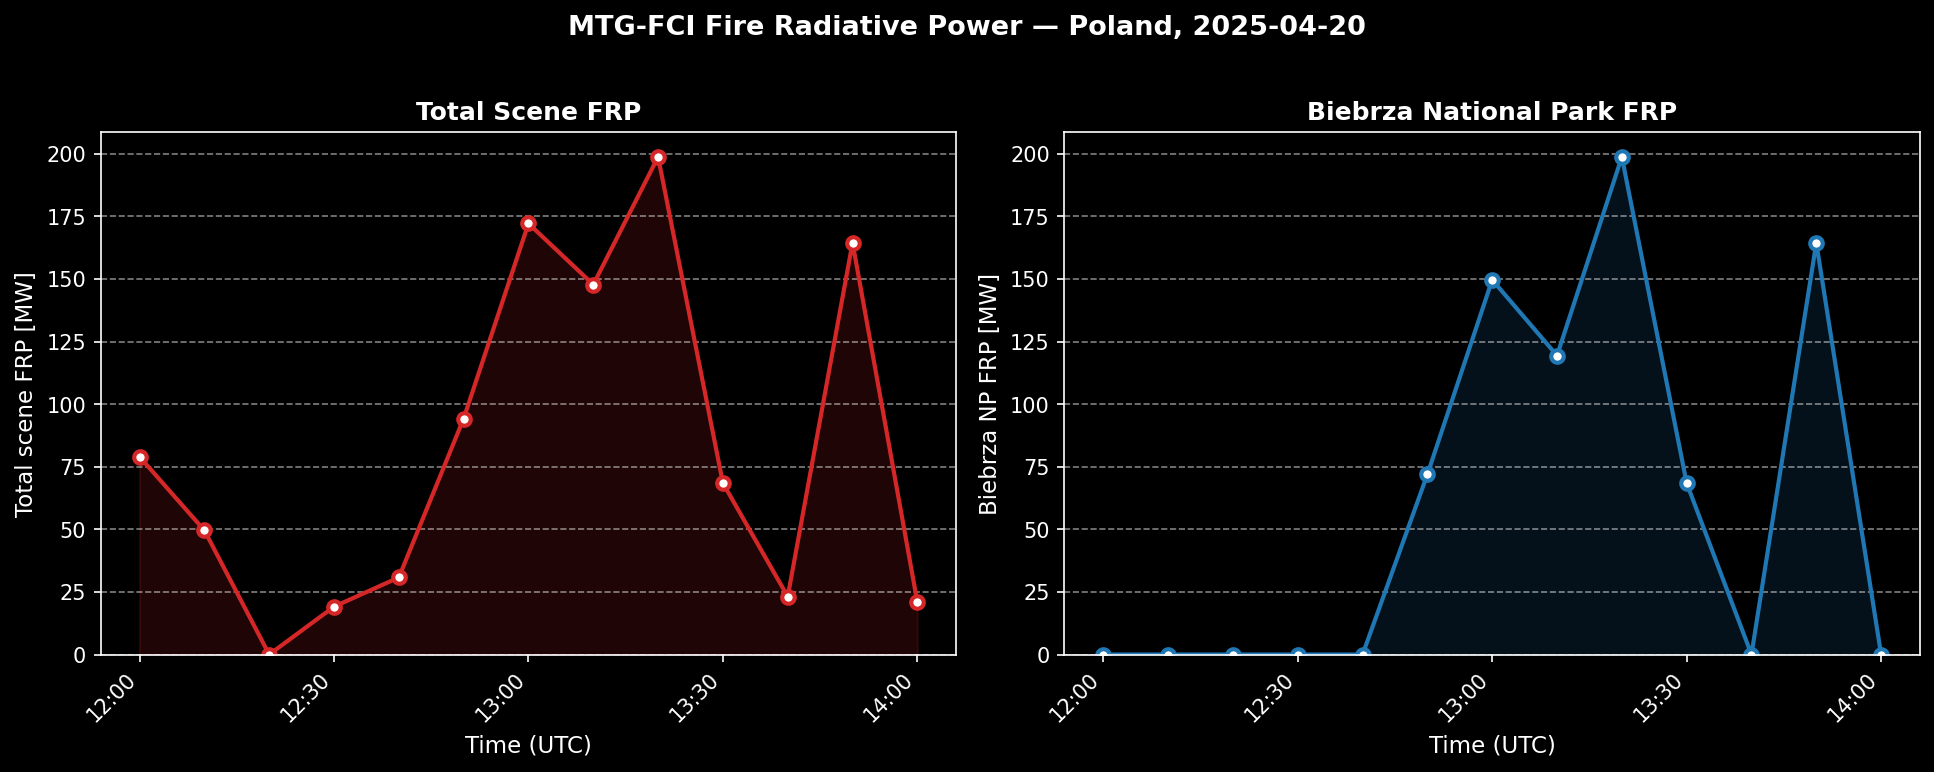

In [21]:
def plot_frp_timeseries(timestamps, frp_total, frp_biebrza, figsize=(13, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=150)
    for ax, vals, label, color, title in [
        (axes[0], frp_total, "Total scene FRP [MW]", "#d62728", "Total Scene FRP"),
        (axes[1], frp_biebrza, "Biebrza NP FRP [MW]", "#1f77b4", "Biebrza National Park FRP"),
    ]:
        ax.plot(timestamps, vals, marker="o", linewidth=2, color=color,
                markerfacecolor="white", markeredgewidth=2)
        ax.fill_between(timestamps, vals, alpha=0.15, color=color)
        ax.set_xlabel("Time (UTC)", fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(title, fontweight="bold", fontsize=12)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 30)))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylim(bottom=0)
    fig.suptitle("MTG-FCI Fire Radiative Power — Poland, 2025-04-20",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    return fig


if timestamps and frp_total_ts:
    plot_frp_timeseries(timestamps, frp_total_ts, frp_biebrza_ts)

### 7.2 Cumulative Fire Radiative Energy (FRE)

$$\text{FRE} = \sum_{i} \text{FRP}_i \times \Delta t$$

FRE measures the **total energy released**, correlating with fuel consumption and emissions.

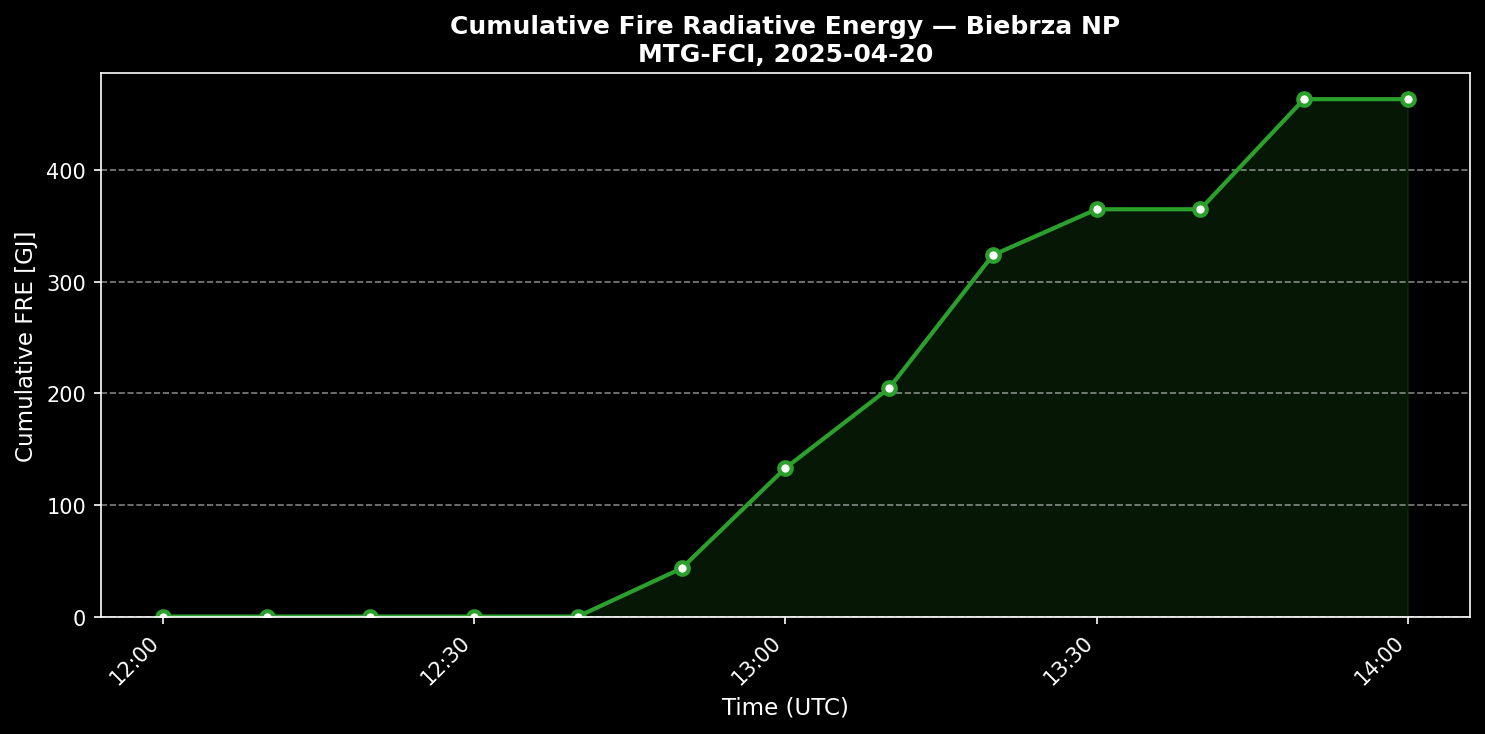

In [22]:
def plot_cumulative_frp(timestamps, frp_biebrza, figsize=(10, 5)):
    dt_seconds = 10 * 60
    fre = [frp * dt_seconds for frp in frp_biebrza]
    cumulative_fre = np.cumsum(fre)
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.plot(timestamps, cumulative_fre / 1e3, marker="o", linewidth=2,
            color="#2ca02c", markerfacecolor="white", markeredgewidth=2)
    ax.fill_between(timestamps, cumulative_fre / 1e3, alpha=0.15, color="#2ca02c")
    ax.set_xlabel("Time (UTC)", fontsize=11)
    ax.set_ylabel("Cumulative FRE [GJ]", fontsize=11)
    ax.set_title("Cumulative Fire Radiative Energy — Biebrza NP\nMTG-FCI, 2025-04-20",
                 fontweight="bold", fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 30)))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()
    return fig


if timestamps and frp_biebrza_ts:
    plot_cumulative_frp(timestamps, frp_biebrza_ts)

## 8. Interactive Fire Map

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd


def _serialize_gdf(gdf):
    """Convert datetime/Timestamp columns to strings for JSON-safe GeoJSON export."""
    gdf = gdf.copy()
    for col in gdf.columns:
        if col == "geometry":
            continue
        if pd.api.types.is_datetime64_any_dtype(gdf[col]):
            gdf[col] = gdf[col].astype(str)
        elif gdf[col].dtype == object and len(gdf) > 0:
            sample = gdf[col].dropna()
            if len(sample) > 0 and hasattr(sample.iloc[0], "strftime"):
                gdf[col] = gdf[col].apply(lambda x: str(x) if x is not None else x)
    return gdf


def build_interactive_map(gdf):
    from shapely.geometry import box
    center_lat = (BIEBRZA_BBOX["lat_min"] + BIEBRZA_BBOX["lat_max"]) / 2
    center_lon = (BIEBRZA_BBOX["lon_min"] + BIEBRZA_BBOX["lon_max"]) / 2
    m = leafmap.Map(center=[center_lat, center_lon], zoom=10)
    m.add_basemap("Esri.WorldImagery")
    if not gdf.empty:
        m.add_gdf(_serialize_gdf(gdf), layer_name="Fire Detections",
                  style={"color": "red", "fillColor": "orange", "fillOpacity": 0.65, "radius": 4, "weight": 1})
    biebrza_poly = gpd.GeoDataFrame(
        geometry=[box(BIEBRZA_BBOX["lon_min"], BIEBRZA_BBOX["lat_min"],
                      BIEBRZA_BBOX["lon_max"], BIEBRZA_BBOX["lat_max"])], crs="EPSG:4326")
    m.add_gdf(biebrza_poly, layer_name="Biebrza NP (AOI)",
              style={"color": "#2ca02c", "fillOpacity": 0.04, "weight": 2})
    return m


if not gdf_all.empty:
    unique_dts = sorted(gdf_all["DATETIME"].dropna().unique(), key=str)

    dropdown = widgets.Dropdown(
        options=[("All timestamps", None)] + [
            (dt.strftime("%Y-%m-%d %H:%M UTC"), dt) for dt in unique_dts
        ],
        description="Date/Time:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="380px"),
    )
    out = widgets.Output()


    def on_change(change):
        if change["name"] != "value":
            return
        with out:
            clear_output(wait=True)
            sel = change["new"]
            sub = gdf_all if sel is None else gdf_all[gdf_all["DATETIME"] == sel]
            display(build_interactive_map(sub))


    dropdown.observe(on_change, names="value")

    with out:
        display(build_interactive_map(gdf_all))

    display(dropdown, out)

    map_path = OUTPUT_DIR / "fire_map_all_timestamps.html"
    #build_interactive_map(gdf_all).to_html(str(map_path))
    #print(f"Interactive map saved to: {map_path}")

Dropdown(description='Date/Time:', layout=Layout(width='380px'), options=(('All timestamps', None), ('2025-04-…

Output()

## 9. Export Results

In [24]:
if not gdf_all.empty:
    out_path = OUTPUT_DIR / "fire_detections_all_timestamps.geojson"
    gdf_all.to_file(out_path)
    print(f"Saved {len(gdf_all)} fire detections to: {out_path}")
    print(f"\nSummary:")
    print(f"  Timestamps: {len(timestamps)}, Detections: {len(gdf_all)}")
    print(f"  Peak scene FRP: {max(frp_total_ts):.1f} MW")
    print(f"  Peak Biebrza FRP: {max(frp_biebrza_ts):.1f} MW")
    for dt, ft, fb in zip(timestamps, frp_total_ts, frp_biebrza_ts):
        print(f"    {dt.strftime('%H:%M UTC')}: FRP={ft:.1f} MW (Biebrza: {fb:.1f} MW)")

Saved 28 fire detections to: /home/michal/agh/rsaia-labs/lab_4/output/fire_detections_all_timestamps.geojson

Summary:
  Timestamps: 13, Detections: 28
  Peak scene FRP: 198.8 MW
  Peak Biebrza FRP: 198.8 MW
    12:00 UTC: FRP=79.0 MW (Biebrza: 0.0 MW)
    12:10 UTC: FRP=49.6 MW (Biebrza: 0.0 MW)
    12:20 UTC: FRP=0.0 MW (Biebrza: 0.0 MW)
    12:30 UTC: FRP=19.1 MW (Biebrza: 0.0 MW)
    12:40 UTC: FRP=30.8 MW (Biebrza: 0.0 MW)
    12:50 UTC: FRP=94.2 MW (Biebrza: 72.0 MW)
    13:00 UTC: FRP=172.2 MW (Biebrza: 149.7 MW)
    13:10 UTC: FRP=147.8 MW (Biebrza: 119.4 MW)
    13:20 UTC: FRP=198.8 MW (Biebrza: 198.8 MW)
    13:30 UTC: FRP=68.5 MW (Biebrza: 68.5 MW)
    13:40 UTC: FRP=23.1 MW (Biebrza: 0.0 MW)
    13:50 UTC: FRP=164.5 MW (Biebrza: 164.5 MW)
    14:00 UTC: FRP=20.9 MW (Biebrza: 0.0 MW)


---

## Summary

We implemented a complete **active fire detection pipeline** using **MTG-FCI** satellite data:

1. **Data ingestion:** Extracted and co-registered FDHSI (~2 km) and HRFI (~1 km) bands
2. **Cloud masking:** Threshold-based mask using visible, NIR, and thermal channels
3. **Potential fire detection:** MWIR brightness temperature and MWIR–TIR difference thresholds
4. **Contextual confirmation:** MODIS Collection 5 algorithm (C1–C4 tests)
5. **FRP estimation:** Wooster/MODIS equation
6. **Temporal analysis:** 13 timestamps at 10-minute intervals
7. **Visualization:** Static plots and interactive leafmap maps

### Key takeaways

- **Geostationary satellites** like MTG provide 10-minute temporal resolution for fire monitoring
- The **3.8 µm MWIR channel** is uniquely sensitive to fire temperatures
- **Contextual algorithms** reduce false alarms via local background comparison
- **FRP timeseries** track fire intensity and energy release in near-real time

### References

- Giglio, L. et al. (2003). An enhanced contextual fire detection algorithm for MODIS. *Remote Sensing of Environment*, 87(2-3), 273-282.
- Wooster, M.J. et al. (2005). Retrieval of biomass combustion rates and totals from fire radiative power observations. *JGR*, 110(D24).
- Copernicus EMS activation EMSR780: Biebrza National Park wildfire (April 2025).